# Notebook 3.3: Early Fusion ML (Ảnh WSI + Gen RNA-Seq)
**Mục tiêu:** Kiểm chứng sức mạnh "God Mode" của dữ liệu Gen khi kết hợp bằng thuật toán Machine Learning truyền thống.

**Cơ chế Early Fusion:**
1. **Ảnh WSI:** Mean Pooling, nén PCA xuống 256 chiều.
2. **Genomics:** Lọc phương sai 500 gen biến động mạnh nhất từ 20,500 gen.
3. **Hợp nhất (Early Fusion):** Nối (256 + 500 = 756 chiều). Đưa vào SVM, Random Forest, XGBoost để đánh giá giới hạn sức mạnh của Early Fusion.

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

### 1. Xử lý Ảnh WSI (Mean Pooling) và Lọc 500 Gen (Variance Threshold)

In [2]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files'
RNASEQ_FILE = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/data_mrna_seq_v2_rsem.txt'
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

print("Đang lọc 500 gen có biến động mạnh nhất từ RNA-Seq...")
rna_df = pd.read_csv(RNASEQ_FILE, sep='\t')
if 'Entrez_Gene_Id' in rna_df.columns:
    rna_df = rna_df.drop(columns=['Entrez_Gene_Id'])

rna_df = rna_df.set_index('Hugo_Symbol').T
rna_df.index = rna_df.index.str[:12]
rna_df = rna_df[~rna_df.index.duplicated(keep='first')]
rna_df = rna_df.dropna(axis=1)

variances = rna_df.var()
top_500_genes = variances.nlargest(500).index
rna_500 = rna_df[top_500_genes]

scaler = StandardScaler()
rna_500_scaled = pd.DataFrame(scaler.fit_transform(rna_500), index=rna_500.index)

df_clin = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df_clin.columns) < 5:
    df_clin = pd.read_csv(CLINICAL_CSV)
valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_clin = df_clin[df_clin['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_clin['label'] = df_clin['pam50_subtype'].map(label_map)
label_dict = dict(zip(df_clin['patientId'], df_clin['label']))

valid_pids = []
for pid in label_dict.keys():
    if pid in rna_500_scaled.index and os.path.exists(os.path.join(PT_DIR, f"{pid}.pt")):
        valid_pids.append(pid)

X_img = []
X_gen = []
y = []

for pid in tqdm(valid_pids, desc="Trích xuất đặc trưng"):
    features = torch.load(os.path.join(PT_DIR, f"{pid}.pt"), map_location='cpu').numpy()
    img_feat = np.mean(features, axis=0)
    
    X_img.append(img_feat)
    X_gen.append(rna_500_scaled.loc[pid].values.astype(np.float32))
    y.append(label_dict[pid])

X_img = np.array(X_img)
X_gen = np.array(X_gen)
y = np.array(y)

Đang lọc 500 gen có biến động mạnh nhất từ RNA-Seq...


Trích xuất đặc trưng: 100%|██████████| 882/882 [00:23<00:00, 37.23it/s]


### 2. Nén Hình Ảnh (PCA) và Nối Dữ Liệu (Early Fusion)
Ép 2048 chiều ảnh xuống 256 chiều, sau đó nối với 500 chiều gen để tạo thành siêu vector 756 chiều.

In [3]:
print(f"Kích thước ảnh ban đầu: {X_img.shape}")
pca = PCA(n_components=256, random_state=42)
X_img_pca = pca.fit_transform(X_img)
print(f"Kích thước ảnh sau PCA: {X_img_pca.shape}")

X_fusion = np.concatenate((X_img_pca, X_gen), axis=1)
print(f"Kích thước siêu vector Đa phương thức (Gen + Ảnh): {X_fusion.shape}")

Kích thước ảnh ban đầu: (882, 2048)
Kích thước ảnh sau PCA: (882, 256)
Kích thước siêu vector Đa phương thức (Gen + Ảnh): (882, 756)


### 3. Đánh Giá Baseline ML Truyền Thống Đa Phương Thức

In [4]:
# 1. Khởi tạo các Classifier cơ sở
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
svm_clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
log_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
xgb_clf = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('svm', svm_clf),
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

models = {
    'SVM RBF': svm_clf,
    'Logistic Regression': log_clf,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf,
    'Voting Ensemble': voting_clf
}

y_data = y
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    cv_res = cross_validate(model, X_fusion, y_data, cv=skf, scoring=('accuracy', 'f1_macro'), n_jobs=-1)
    
    mean_acc = cv_res['test_accuracy'].mean()
    std_acc = cv_res['test_accuracy'].std()
    mean_f1 = cv_res['test_f1_macro'].mean()
    std_f1 = cv_res['test_f1_macro'].std()
    
    results.append({
        'Model': name,
        'Accuracy (Mean ± Std)': f"{mean_acc:.4f} ± {std_acc:.4f}",
        'Macro-F1 (Mean ± Std)': f"{mean_f1:.4f} ± {std_f1:.4f}",
        'Raw_F1': mean_f1
    })

results_df = pd.DataFrame(results).sort_values(by='Raw_F1', ascending=False)
print("\n🏆 BẢNG XẾP HẠNG ML EARLY FUSION (WSI + GENOMICS):")
print(results_df[['Model', 'Accuracy (Mean ± Std)', 'Macro-F1 (Mean ± Std)']].to_string(index=False))

# Xuất bảng kết quả 5-Fold CSV
results_df.to_csv("/kaggle/working/ml_genomics_fusion_5fold_results.csv", index=False)

# Huấn luyện và lưu model tốt nhất (joblib)
import joblib
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models[best_model_name]
best_model_obj.fit(X_fusion, y_data)
clean_name = best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
joblib.dump(best_model_obj, f"/kaggle/working/ml_genomics_fusion_{clean_name}_best_model.joblib")

print("✓ Đã lưu bảng điểm 5-Fold (.csv) và mô hình tốt nhất (.joblib) vào /kaggle/working/")

Đang huấn luyện SVM RBF...
Đang huấn luyện Logistic Regression...
Đang huấn luyện Random Forest...
Đang huấn luyện XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Đang huấn luyện Voting Ensemble...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:32:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:32:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:32:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:32:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

,Model,Accuracy (Mean ± Std),Macro-F1 (Mean ± Std)
3,XGBoost,0.8753 ± 0.0214,0.8588 ± 0.0255
4,Voting Ensemble,0.8662 ± 0.0303,0.8487 ± 0.0296
2,Random Forest,0.8469 ± 0.0172,0.8143 ± 0.0242
1,Logistic Regression,0.8254 ± 0.0279,0.8090 ± 0.0367
0,SVM RBF,0.8299 ± 0.0157,0.8042 ± 0.0167


### 4. Trực Quan Hóa (Confusion Matrix)

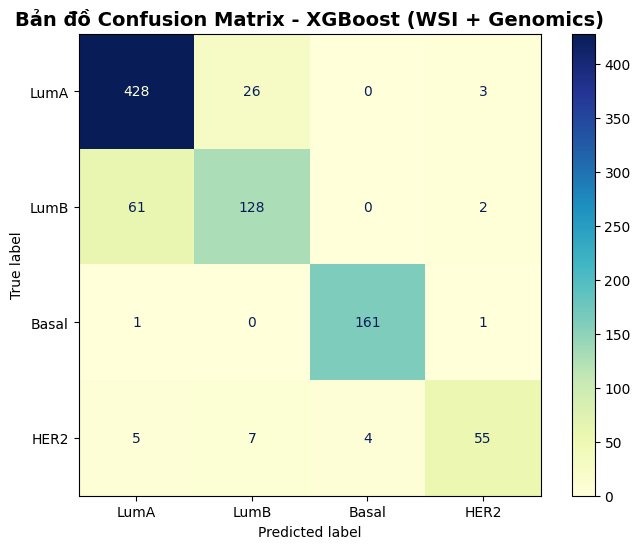

In [5]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

all_preds = []
all_targets = []

for train_idx, test_idx in skf.split(X_fusion, y_data):
    X_train, X_test = X_fusion[train_idx], X_fusion[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]
    
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)
    
    all_preds.extend(preds)
    all_targets.extend(y_test)

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix - {best_model_name} (WSI + Genomics Early Fusion)', fontsize=14, fontweight='bold')
plt.show()